In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("AccidentsBig.csv", low_memory=False)
print("Shape:", df.shape)
print(df.head())

Shape: (1048575, 30)
   Accident_Index  longitude   latitude  Police_Force  Accident_Severity  \
0             1.0  78.610393  14.724026           1.0                2.0   
1             2.0  78.534042  14.762353           1.0                3.0   
2             3.0  78.470877  14.745606           1.0                3.0   
3             4.0  78.557994  14.667128           1.0                3.0   
4             5.0  78.576431  14.703443           1.0                3.0   

   Number_of_Vehicles  Number_of_Casualties  Day_of_Week   Time  \
0                 1.0                   1.0          3.0  17:42   
1                 1.0                   1.0          4.0  17:36   
2                 2.0                   1.0          5.0  00:15   
3                 1.0                   1.0          6.0  10:35   
4                 1.0                   1.0          2.0  21:13   

   Local_Authority_(District)  ... Pedestrian_Crossing-Physical_Facilities  \
0                        12.0  ...       

In [3]:
# Check nulls
print("Null values:\n", df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()
print("Shape after duplicates removed:", df.shape)

# Drop irrelevant columns
df = df.drop(columns=[
    'Accident_Index', 'Date', 'Time', 'latitude', 'longitude',
    'Police_Force', 'Local_Authority_(District)',
    'Local_Authority_(Highway)', 'LSOA_of_Accident_Location',
    'Pedestrian_Crossing-Human_Control',
    'Pedestrian_Crossing-Physical_Facilities',
    'Did_Police_Officer_Attend_Scene_of_Accident',
    '2nd_Road_Class', '2nd_Road_Number'
])

print("Remaining columns:", df.columns.tolist())
print("Shape after dropping columns:", df.shape)

Null values:
 Accident_Index                                 988577
longitude                                      988577
latitude                                       988577
Police_Force                                   988577
Accident_Severity                              988577
Number_of_Vehicles                             988577
Number_of_Casualties                           988577
Day_of_Week                                    988577
Time                                           988578
Local_Authority_(District)                     988577
Local_Authority_(Highway)                      988577
1st_Road_Class                                 988577
1st_Road_Number                                988577
Road_Type                                      988577
Speed_limit                                    988577
Junction_Detail                                988577
Junction_Control                               988577
2nd_Road_Class                                 988577
2nd_Road_Numbe

In [4]:
# Convert 1,2,3 to Fatal, Serious, Slight
df['Accident_Severity'] = df['Accident_Severity'].map({
    1.0: 'Fatal',
    2.0: 'Serious',
    3.0: 'Slight'
})

# Drop rows where severity is null
df = df.dropna(subset=['Accident_Severity'])

print("Target distribution:\n", df['Accident_Severity'].value_counts())

Target distribution:
 Accident_Severity
Slight     51975
Serious     7377
Fatal        646
Name: count, dtype: int64


In [5]:
# Fill numerical nulls with median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Drop remaining null rows
df = df.dropna()

print("Shape after handling nulls:", df.shape)
print("Remaining nulls:\n", df.isnull().sum())

Shape after handling nulls: (59998, 16)
Remaining nulls:
 Accident_Severity             0
Number_of_Vehicles            0
Number_of_Casualties          0
Day_of_Week                   0
1st_Road_Class                0
1st_Road_Number               0
Road_Type                     0
Speed_limit                   0
Junction_Detail               0
Junction_Control              0
Light_Conditions              0
Weather_Conditions            0
Road_Surface_Conditions       0
Special_Conditions_at_Site    0
Carriageway_Hazards           0
Urban_or_Rural_Area           0
dtype: int64


In [6]:
# Night time flag (8PM to 6AM)
df['is_night'] = df['Day_of_Week'].apply(lambda x: 1 if x in [1, 7] else 0)

# High speed flag
df['high_speed'] = df['Speed_limit'].apply(lambda x: 1 if x >= 60 else 0)

# Multi vehicle flag
df['multi_vehicle'] = df['Number_of_Vehicles'].apply(lambda x: 1 if x > 1 else 0)

# High casualty flag
df['high_casualty'] = df['Number_of_Casualties'].apply(lambda x: 1 if x > 2 else 0)

# Bad light flag
df['bad_light'] = df['Light_Conditions'].apply(lambda x: 1 if x != 1 else 0)

# Bad weather flag
df['bad_weather'] = df['Weather_Conditions'].apply(lambda x: 1 if x != 1 else 0)

# Bad road surface flag
df['bad_surface'] = df['Road_Surface_Conditions'].apply(lambda x: 1 if x != 1 else 0)

print("New features added!")
print("Shape:", df.shape)

New features added!
Shape: (59998, 23)


In [7]:
print("Before business logic:", df.shape)

# Speed limit: 10 to 100 kmph
df = df[(df['Speed_limit'] >= 10) & (df['Speed_limit'] <= 100)]

# Vehicles: 1 to 20
df = df[(df['Number_of_Vehicles'] >= 1) & (df['Number_of_Vehicles'] <= 20)]

# Casualties: 0 to 50
df = df[(df['Number_of_Casualties'] >= 0) & (df['Number_of_Casualties'] <= 50)]

print("After business logic:", df.shape)

Before business logic: (59998, 23)
After business logic: (59998, 23)


In [8]:
print("Before std removal:", df.shape)

numerical_cols = ['Speed_limit', 'Number_of_Vehicles', 'Number_of_Casualties']

for col in numerical_cols:
    mean = df[col].mean()
    std  = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After std removal:", df.shape)

Before std removal: (59998, 23)
After std removal: (55106, 23)


In [9]:
le_target = LabelEncoder()
df['Accident_Severity'] = le_target.fit_transform(df['Accident_Severity'])

print("Classes:", le_target.classes_)
print("Target distribution:\n", pd.Series(df['Accident_Severity']).value_counts())

Classes: ['Fatal' 'Serious' 'Slight']
Target distribution:
 Accident_Severity
2    47896
1     6708
0      502
Name: count, dtype: int64


In [10]:
X = df.drop(columns=['Accident_Severity'])
y = df['Accident_Severity']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (55106, 22)
y distribution:
 Accident_Severity
2    47896
1     6708
0      502
Name: count, dtype: int64


In [11]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {2: 47896, 1: 6708, 0: 502}
After SMOTE: {1: 47896, 2: 47896, 0: 47896}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (114950, 22)
Testing size: (28738, 22)


In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [14]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='accuracy')

print("K-Fold Scores:", cv_scores)
print("Mean Accuracy:", round(cv_scores.mean()*100, 2), "%")
print("Std Dev:", round(cv_scores.std()*100, 2), "%")

K-Fold Scores: [0.89134406 0.89312745 0.8939104  0.89478034 0.89504132]
Mean Accuracy: 89.36 %
Std Dev: 0.13 %


In [15]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [16]:
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Test Accuracy: 88.84 %

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.96      0.97      0.97      9602
     Serious       0.91      0.77      0.83      9515
      Slight       0.81      0.92      0.86      9621

    accuracy                           0.89     28738
   macro avg       0.89      0.89      0.89     28738
weighted avg       0.89      0.89      0.89     28738



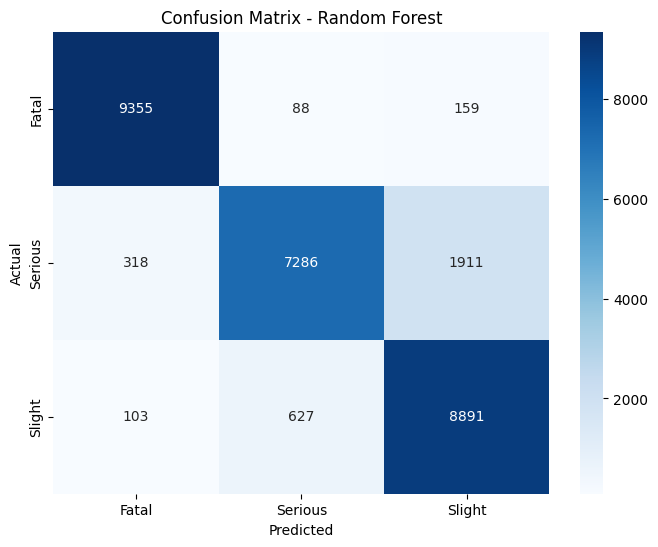

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Top 10 Most Dangerous Roads:
     1st_Road_Number  accident_count   is_blackspot
0                0.0           17683  BLACK SPOT ⚠️
6                6.0             636  BLACK SPOT ⚠️
4                4.0             472  BLACK SPOT ⚠️
314            406.0             457  BLACK SPOT ⚠️
20              23.0             429  BLACK SPOT ⚠️
46              57.0             402  BLACK SPOT ⚠️
33              40.0             389           Safe
45              56.0             380           Safe
48              59.0             354           Safe
871           4020.0             334           Safe


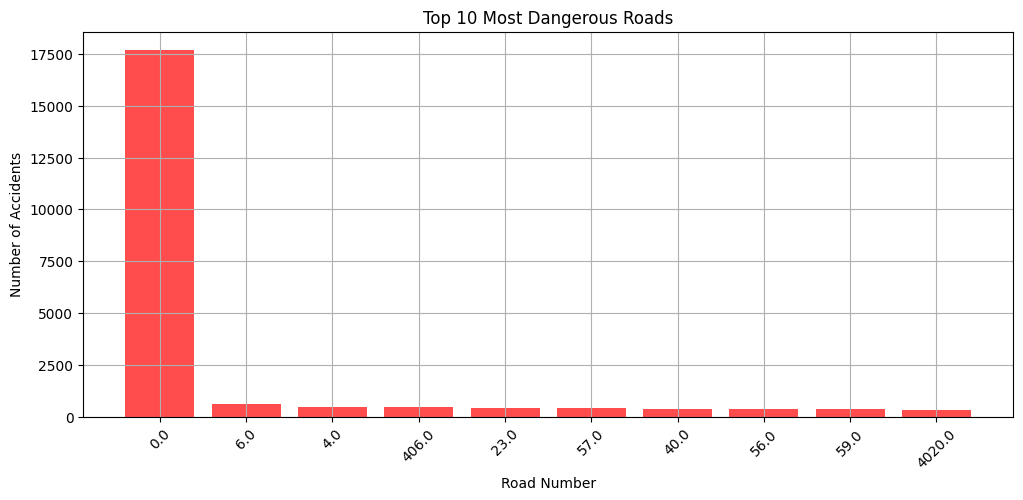

In [18]:
# Group by road number and count accidents
blackspots = df.groupby('1st_Road_Number').size().reset_index(name='accident_count')
blackspots = blackspots.sort_values('accident_count', ascending=False)

# Flag roads with more than 400 accidents as black spots
blackspots['is_blackspot'] = blackspots['accident_count'].apply(
    lambda x: 'BLACK SPOT ⚠️' if x >= 400 else 'Safe'
)

print("Top 10 Most Dangerous Roads:")
print(blackspots.head(10))

# Plot
plt.figure(figsize=(12, 5))
plt.bar(blackspots.head(10)['1st_Road_Number'].astype(str),
        blackspots.head(10)['accident_count'],
        color='red', alpha=0.7)
plt.title("Top 10 Most Dangerous Roads")
plt.xlabel("Road Number")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [19]:
print(f"{'Actual':<15} {'Predicted':<15} {'Result':<10}")
print("-" * 40)

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    actual_name    = le_target.classes_[actual]
    predicted_name = le_target.classes_[predicted]
    match = "Correct" if actual == predicted else "Wrong"
    print(f"{actual_name:<15} {predicted_name:<15} {match:<10}")

Actual          Predicted       Result    
----------------------------------------
Serious         Serious         Correct   
Serious         Serious         Correct   
Serious         Slight          Wrong     
Slight          Slight          Correct   
Fatal           Fatal           Correct   
Fatal           Fatal           Correct   
Fatal           Fatal           Correct   
Serious         Serious         Correct   
Slight          Slight          Correct   
Slight          Slight          Correct   


In [20]:
with open("rf_model_new.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open("scaler_new.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("blackspots.pkl", "wb") as f:
    pickle.dump(blackspots, f)

print("Model, Scaler and Blackspots saved successfully!")

Model, Scaler and Blackspots saved successfully!


In [21]:
model_info = {
    "features": list(X.columns),
    "target_classes": list(le_target.classes_),
    "model_accuracy": round(accuracy_score(y_test, y_pred)*100, 2),
    "total_accidents": int(len(df)),
    "blackspot_roads": blackspots[blackspots['is_blackspot'] == 'BLACK SPOT ⚠️']['1st_Road_Number'].tolist()
}

with open("model_info_new.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model info saved!")
print(json.dumps(model_info, indent=4))

Model info saved!
{
    "features": [
        "Number_of_Vehicles",
        "Number_of_Casualties",
        "Day_of_Week",
        "1st_Road_Class",
        "1st_Road_Number",
        "Road_Type",
        "Speed_limit",
        "Junction_Detail",
        "Junction_Control",
        "Light_Conditions",
        "Weather_Conditions",
        "Road_Surface_Conditions",
        "Special_Conditions_at_Site",
        "Carriageway_Hazards",
        "Urban_or_Rural_Area",
        "is_night",
        "high_speed",
        "multi_vehicle",
        "high_casualty",
        "bad_light",
        "bad_weather",
        "bad_surface"
    ],
    "target_classes": [
        "Fatal",
        "Serious",
        "Slight"
    ],
    "model_accuracy": 88.84,
    "total_accidents": 55106,
    "blackspot_roads": [
        0.0,
        6.0,
        4.0,
        406.0,
        23.0,
        57.0
    ]
}
